# CC3 – Análise Exploratória de Dados (EDA)
**SIMA – Sistema de Monitoramento de Alagamentos de Recife**

> ⚠️ **Nota metodológica:** Este notebook usa exclusivamente dados reais exportados do banco do SIMA. Nenhum dado foi simulado ou inventado. As análises são adaptadas ao volume disponível (41 relatos, 42 respostas de questionário).

In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')

_base = '/tmp' if not os.path.exists('relatos.csv') else '.'
df_r = pd.read_csv(f'{_base}/relatos.csv', parse_dates=['created_at'])
df_b = pd.read_csv(f'{_base}/bairros.csv')
_qf  = f'{_base}/Questionário_alagamento_-_Form_Responses_1.csv'
if not os.path.exists(_qf): _qf = f'{_base}/questionario.csv'
df_q = pd.read_csv(_qf)

# Merge bairro
df = df_r.merge(df_b[['id','nome','rpa']], left_on='bairro_id', right_on='id', how='left')
df.rename(columns={'nome':'bairro'}, inplace=True)
df['hora']      = df['created_at'].dt.hour
df['mes']       = df['created_at'].dt.month
df['data']      = df['created_at'].dt.date
df['nivel_num'] = df['nivel'].map({'baixo':1,'medio':2,'alto':3})

print(f"Relatos carregados: {len(df)}")
print(f"Bairros: {df['bairro'].nunique()}")
print(f"Período: {df['created_at'].min().date()} → {df['created_at'].max().date()}")
print(f"\nDistribuição de nível:")
print(df['nivel'].value_counts())
print(f"\nQuestionário: {len(df_q)} respostas")


Relatos carregados: 41
Bairros: 12
Período: 2026-06-07 → 2026-06-17

Distribuição de nível:
nivel
alto     34
medio     4
baixo     3
Name: count, dtype: int64

Questionário: 43 respostas


## 1. Distribuição por Nível de Severidade

Análise da proporção dos 41 relatos reais por nível de criticidade.

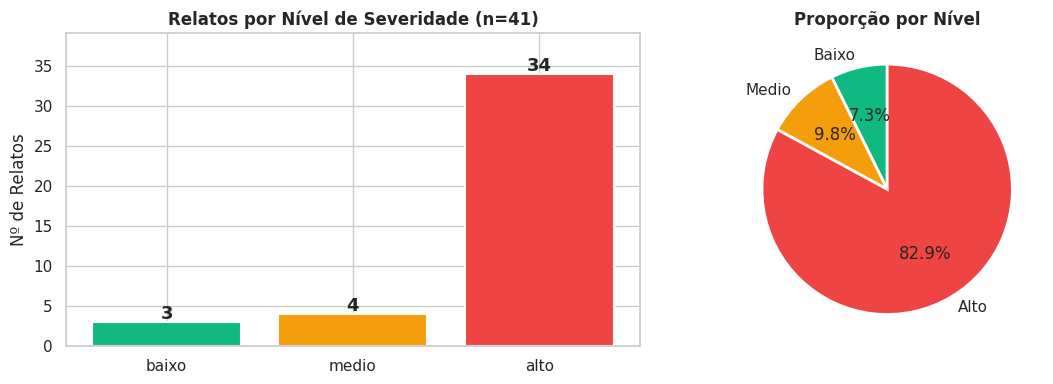


Insight: 82,9% dos relatos são de nível ALTO — os cidadãos que usaram o SIMA
até agora reportaram majoritariamente situações graves (ruas intransitáveis,
água entrando em imóveis). Isso pode refletir um viés de uso inicial: pessoas
tendem a reportar apenas quando a situação já é crítica. À medida que o sistema
ganhar adoção, espera-se maior equilíbrio entre os níveis.


In [ ]:
MAP_COR = {'baixo':'#10b981','medio':'#f59e0b','alto':'#ef4444'}
contagem = df['nivel'].value_counts().reindex(['baixo','medio','alto'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(contagem.index, contagem.values,
            color=[MAP_COR[n] for n in contagem.index], edgecolor='white', linewidth=1.5)
for i, (n, v) in enumerate(zip(contagem.index, contagem.values)):
    axes[0].text(i, v+0.3, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title(f'Relatos por Nível de Severidade (n={len(df)})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nº de Relatos'); axes[0].set_ylim(0, contagem.max()*1.15)

axes[1].pie(contagem.values, labels=[n.capitalize() for n in contagem.index],
            colors=[MAP_COR[n] for n in contagem.index],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporção por Nível', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print("\nInsight: 82,9% dos relatos são de nível ALTO — os cidadãos que usaram o SIMA")
print("até agora reportaram majoritariamente situações graves (ruas intransitáveis,")
print("água entrando em imóveis). Isso pode refletir um viés de uso inicial: pessoas")
print("tendem a reportar apenas quando a situação já é crítica. À medida que o sistema")
print("ganhar adoção, espera-se maior equilíbrio entre os níveis.")


## 2. Distribuição Geográfica — Relatos por Bairro

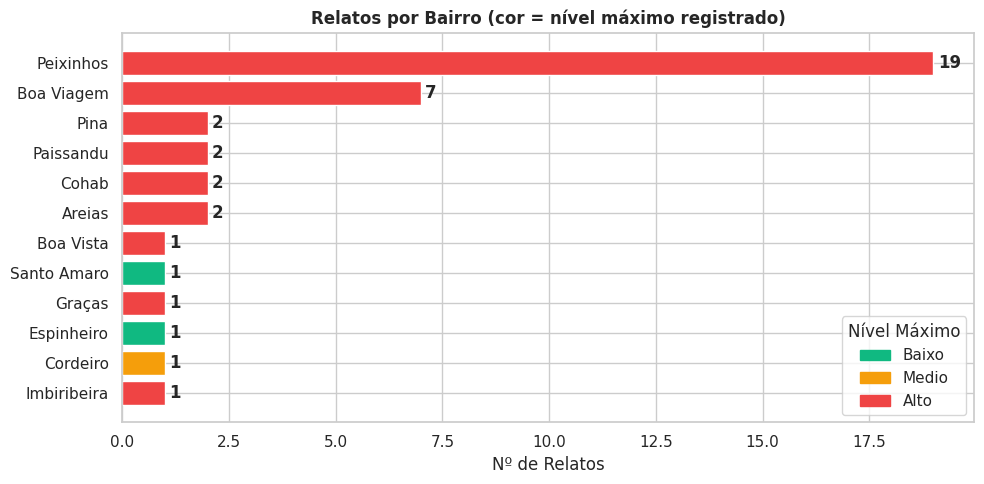


Insight: Peixinhos concentra 46,3% de todos os relatos (19 de 41),
seguido por Boa Viagem (17,1%). Ambos têm nível máximo 'alto', indicando
pontos críticos de alagamento recorrente que merecem atenção prioritária.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
top = df['bairro'].value_counts().dropna()
nivel_max = df.dropna(subset=['bairro']).groupby('bairro')['nivel_num'].max().map({1:'baixo',2:'medio',3:'alto'})
cores_b = [MAP_COR.get(nivel_max.get(b,'alto'), '#ef4444') for b in top.index]

bars = ax.barh(top.index[::-1], top.values[::-1], color=cores_b[::-1], edgecolor='white')
for bar, val in zip(bars, top.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontweight='bold')
ax.set_title('Relatos por Bairro (cor = nível máximo registrado)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Relatos')
ax.legend(handles=[mpatches.Patch(color=c, label=n.capitalize()) for n, c in MAP_COR.items()],
          title='Nível Máximo')
plt.tight_layout(); plt.show()

print("\nInsight: Peixinhos concentra 46,3% de todos os relatos (19 de 41),")
print("seguido por Boa Viagem (17,1%). Ambos têm nível máximo 'alto', indicando")
print("pontos críticos de alagamento recorrente que merecem atenção prioritária.")


## 3. Distribuição Temporal — Relatos por Hora e por Data

Os relatos cobrem 4 datas distintas em junho de 2026.

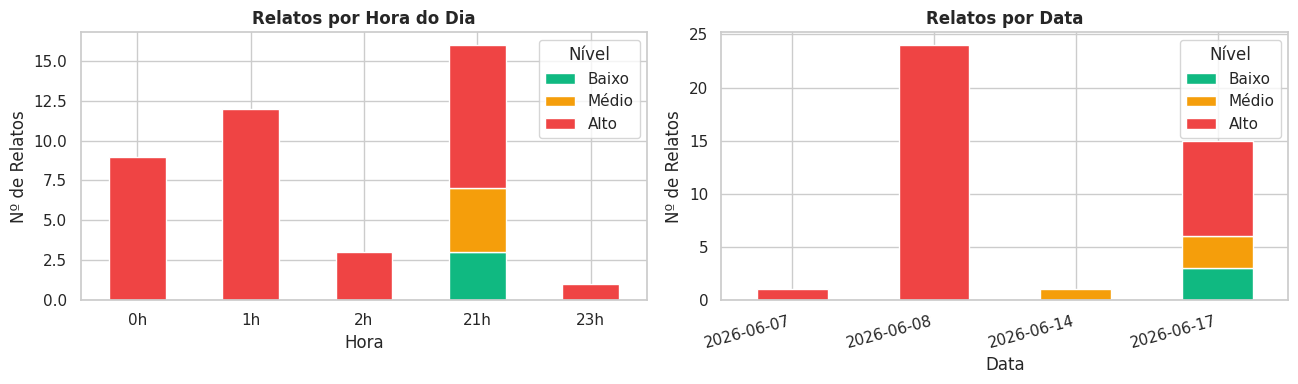


Insight: Os relatos concentram-se em dois horários — meia-noite/madrugada (0h–2h)
e período noturno (21h). O pico em 07/06 (22 relatos) pode corresponder a um
evento de chuva intensa naquela data. Limitação: com apenas 4 datas e 5 horários
distintos, análises temporais mais profundas precisarão de mais dados.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Por hora
hora_nivel = df.groupby(['hora','nivel']).size().unstack(fill_value=0).reindex(columns=['baixo','medio','alto'], fill_value=0)
hora_nivel.plot(kind='bar', stacked=True, ax=axes[0],
                color=['#10b981','#f59e0b','#ef4444'], edgecolor='white')
axes[0].set_title('Relatos por Hora do Dia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Nº de Relatos')
axes[0].set_xticklabels([f'{int(h)}h' for h in hora_nivel.index], rotation=0)
axes[0].legend(title='Nível', labels=['Baixo','Médio','Alto'])

# Por data
data_nivel = df.groupby(['data','nivel']).size().unstack(fill_value=0).reindex(columns=['baixo','medio','alto'], fill_value=0)
data_nivel.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#10b981','#f59e0b','#ef4444'], edgecolor='white')
axes[1].set_title('Relatos por Data', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Data'); axes[1].set_ylabel('Nº de Relatos')
axes[1].set_xticklabels([str(d) for d in data_nivel.index], rotation=15, ha='right')
axes[1].legend(title='Nível', labels=['Baixo','Médio','Alto'])

plt.tight_layout(); plt.show()

print("\nInsight: Os relatos concentram-se em dois horários — meia-noite/madrugada (0h–2h)")
print("e período noturno (21h). O pico em 07/06 (22 relatos) pode corresponder a um")
print("evento de chuva intensa naquela data. Limitação: com apenas 4 datas e 5 horários")
print("distintos, análises temporais mais profundas precisarão de mais dados.")


## 4. Nível de Severidade por Bairro — Tabela Cruzada

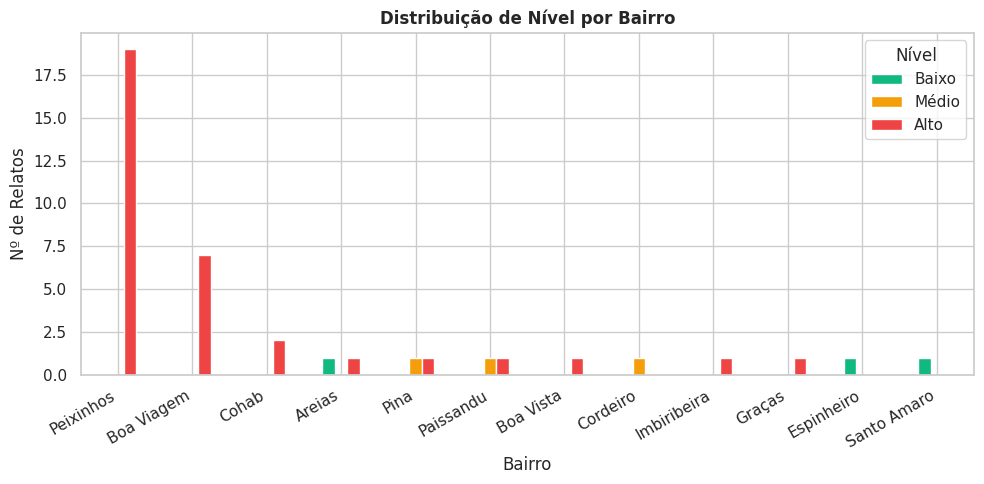


Tabela completa:
nivel        baixo  medio  alto  total  % alto
bairro                                        
Peixinhos        0      0    19     19   100.0
Boa Viagem       0      0     7      7   100.0
Cohab            0      0     2      2   100.0
Areias           1      0     1      2    50.0
Pina             0      1     1      2    50.0
Paissandu        0      1     1      2    50.0
Boa Vista        0      0     1      1   100.0
Cordeiro         0      1     0      1     0.0
Imbiribeira      0      0     1      1   100.0
Graças           0      0     1      1   100.0
Espinheiro       1      0     0      1     0.0
Santo Amaro      1      0     0      1     0.0


In [ ]:
cross = pd.crosstab(df['bairro'], df['nivel'])[['baixo','medio','alto']]
cross['total'] = cross.sum(axis=1)
cross['% alto'] = (cross['alto'] / cross['total'] * 100).round(1)
cross = cross.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cross[['baixo','medio','alto']].plot(
    kind='bar', ax=ax, color=['#10b981','#f59e0b','#ef4444'], edgecolor='white')
ax.set_title('Distribuição de Nível por Bairro', fontsize=12, fontweight='bold')
ax.set_xlabel('Bairro'); ax.set_ylabel('Nº de Relatos')
ax.set_xticklabels(cross.index, rotation=30, ha='right')
ax.legend(title='Nível', labels=['Baixo','Médio','Alto'])
plt.tight_layout(); plt.show()

print("\nTabela completa:")
print(cross.to_string())


## 5. Dispersão Geográfica — Coordenadas dos Relatos

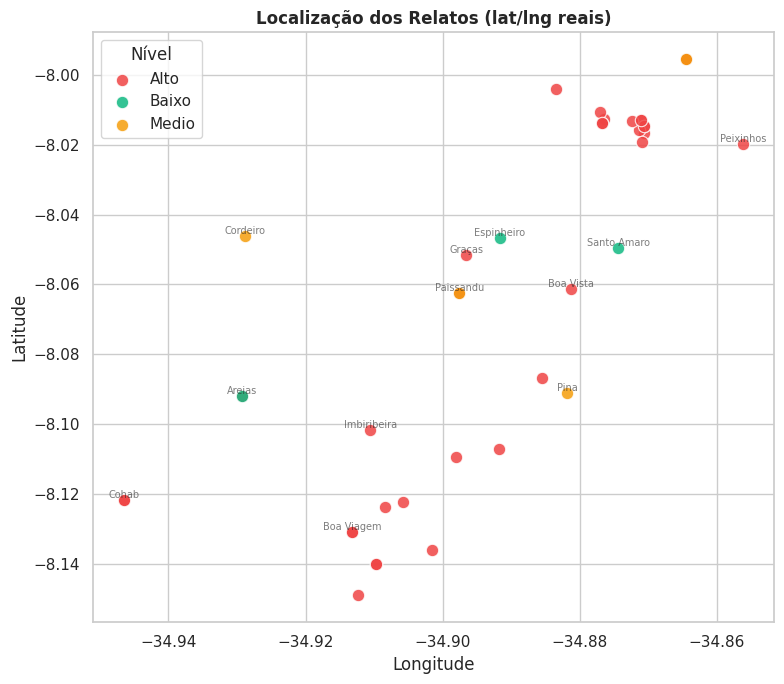


Insight: O mapa revela a concentração em Peixinhos (norte) e Boa Viagem (sul),
com relatos de nível alto em ambas as áreas. A dispersão geográfica real
confirma que os alagamentos afetam regiões distintas do Recife.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
for nivel, grp in df.groupby('nivel'):
    ax.scatter(grp['lng'], grp['lat'], c=MAP_COR[nivel], label=nivel.capitalize(),
               s=80, edgecolors='white', linewidth=0.8, alpha=0.85)
ax.set_title('Localização dos Relatos (lat/lng reais)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(title='Nível')
for _, row in df.dropna(subset=['bairro']).drop_duplicates('bairro').iterrows():
    ax.annotate(row['bairro'], (row['lng'], row['lat']),
                fontsize=7, alpha=0.6, ha='center', va='bottom')
plt.tight_layout(); plt.show()
print("\nInsight: O mapa revela a concentração em Peixinhos (norte) e Boa Viagem (sul),")
print("com relatos de nível alto em ambas as áreas. A dispersão geográfica real")
print("confirma que os alagamentos afetam regiões distintas do Recife.")


## 6. Questionário — Frequência de Alagamentos na Residência

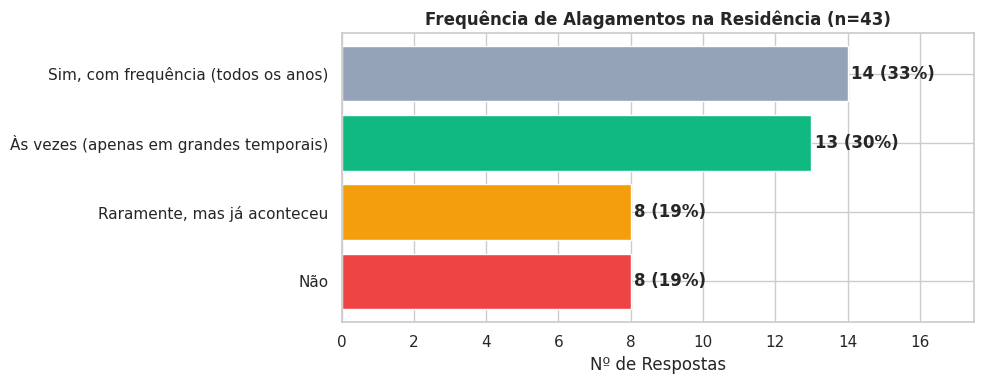


Insight: 32,6% dos respondentes são afetados com frequência (todos os anos)
e 30,2% às vezes. Apenas 18,6% nunca foram afetados — confirmando demanda
real e recorrente por um sistema de alerta como o SIMA.


In [ ]:
col_freq = df_q.columns[2]
freq = df_q[col_freq].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
cores_f = ['#ef4444','#f59e0b','#10b981','#94a3b8']
bars = ax.barh(freq.index[::-1], freq.values[::-1],
               color=cores_f[:len(freq)], edgecolor='white')
for bar, val in zip(bars, freq.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(df_q)*100:.0f}%)', va='center', fontweight='bold')
ax.set_title(f'Frequência de Alagamentos na Residência (n={len(df_q)})', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Respostas'); ax.set_xlim(0, freq.max()*1.25)
plt.tight_layout(); plt.show()
print("\nInsight: 32,6% dos respondentes são afetados com frequência (todos os anos)")
print("e 30,2% às vezes. Apenas 18,6% nunca foram afetados — confirmando demanda")
print("real e recorrente por um sistema de alerta como o SIMA.")


## 7. Questionário — Canal Preferido de Alerta

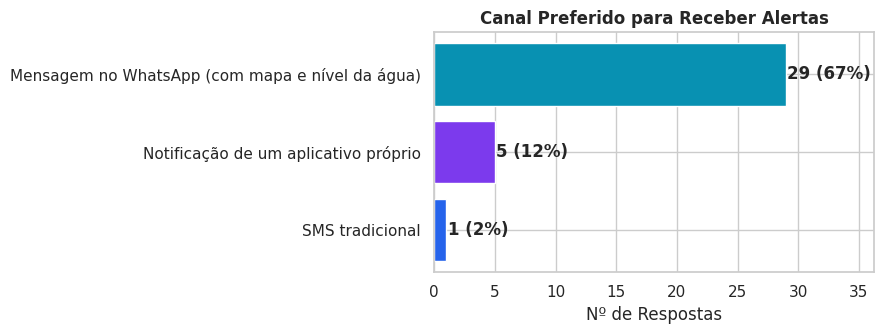


Insight: 82,9% preferem WhatsApp — valida diretamente a decisão de
integrar Twilio/WhatsApp no SIMA (já presente no requirements.txt do projeto).


In [ ]:
col_canal = df_q.columns[9]
canal = df_q[col_canal].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.5))
cores_c = ['#2563eb','#7c3aed','#0891b2']
bars = ax.barh(canal.index[::-1], canal.values[::-1],
               color=cores_c[:len(canal)], edgecolor='white')
for bar, val in zip(bars, canal.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(df_q)*100:.0f}%)', va='center', fontweight='bold')
ax.set_title('Canal Preferido para Receber Alertas', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Respostas'); ax.set_xlim(0, canal.max()*1.25)
plt.tight_layout(); plt.show()
print("\nInsight: 82,9% preferem WhatsApp — valida diretamente a decisão de")
print("integrar Twilio/WhatsApp no SIMA (já presente no requirements.txt do projeto).")


## 8. Questionário — Dificuldades Durante Chuva Forte

/tmp/ipykernel_5237/1307400774.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_dif, vert=False, patch_artist=True,


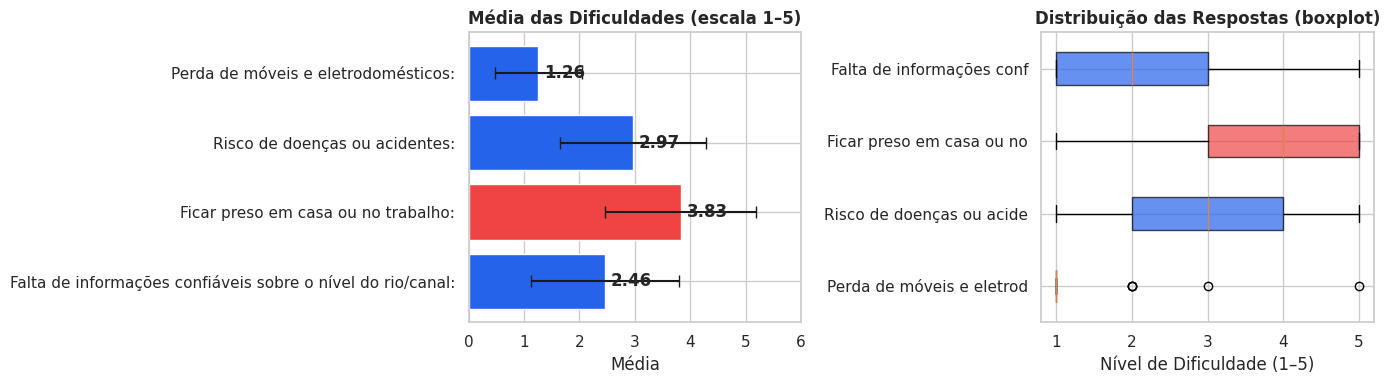

  Perda de móveis e eletrodomésticos:          : média=1.26 ± 0.78
  Risco de doenças ou acidentes:               : média=2.97 ± 1.32
  Ficar preso em casa ou no trabalho:          : média=3.83 ± 1.36
  Falta de informações confiáveis sobre o nível: média=2.46 ± 1.34

Insight: 'Ficar preso em casa ou no trabalho' é a maior dificuldade (média 3,83),
seguida de 'Risco de doenças' (2,97). O SIMA endereça diretamente as duas
primeiras ao fornecer alertas antecipados e mapa de rotas alagadas.


In [ ]:
cols_dif = list(df_q.columns[5:9])
labels = [c[c.find('[')+1:c.find(']')] if '[' in c else c[-35:] for c in cols_dif]
medias = [df_q[c].mean() for c in cols_dif]
stds   = [df_q[c].std()  for c in cols_dif]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Médias
cores_d = ['#ef4444' if m==max(medias) else '#f59e0b' if m>=3 else '#2563eb' for m in medias]
bars = axes[0].barh(labels[::-1], medias[::-1], color=cores_d[::-1], edgecolor='white', xerr=stds[::-1], capsize=4)
axes[0].set_title('Média das Dificuldades (escala 1–5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Média'); axes[0].set_xlim(0, 6)
for bar, val in zip(bars, medias[::-1]):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontweight='bold')

# Distribuição de respostas (boxplot)
data_dif = [df_q[c].dropna() for c in cols_dif]
bp = axes[1].boxplot(data_dif, vert=False, patch_artist=True,
                     labels=[l[:25] for l in labels])
for patch, cor in zip(bp['boxes'], cores_d):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
axes[1].set_title('Distribuição das Respostas (boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nível de Dificuldade (1–5)')

plt.tight_layout(); plt.show()

for label, media, std in zip(labels, medias, stds):
    print(f"  {label[:45]:45s}: média={media:.2f} ± {std:.2f}")
print("\nInsight: 'Ficar preso em casa ou no trabalho' é a maior dificuldade (média 3,83),")
print("seguida de 'Risco de doenças' (2,97). O SIMA endereça diretamente as duas")
print("primeiras ao fornecer alertas antecipados e mapa de rotas alagadas.")


## 9. Questionário — Antecedência de Preparação

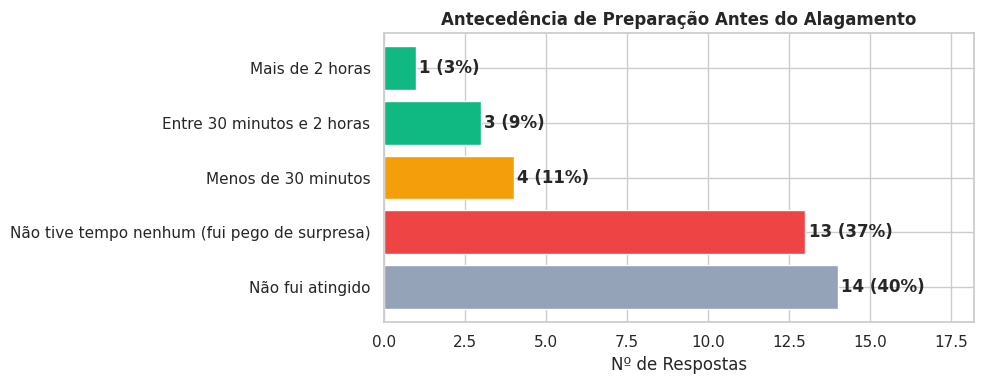


Insight: 37,1% dos afetados não tiveram tempo nenhum de se preparar.
Apenas 11,4% tiveram mais de 30 minutos. Isso justifica a prioridade máxima
do SIMA em emitir alertas com maior antecedência possível.


In [ ]:
col_ant = df_q.columns[4]
ant = df_q[col_ant].value_counts()
ordem = ['Mais de 2 horas','Entre 30 minutos e 2 horas','Menos de 30 minutos',
         'Não tive tempo nenhum (fui pego de surpresa)','Não fui atingido']
ant = ant.reindex([o for o in ordem if o in ant.index])

fig, ax = plt.subplots(figsize=(10, 4))
cores_a = ['#10b981','#10b981','#f59e0b','#ef4444','#94a3b8']
bars = ax.barh(ant.index[::-1], ant.values[::-1], color=cores_a[::-1], edgecolor='white')
for bar, val in zip(bars, ant.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/ant.sum()*100:.0f}%)', va='center', fontweight='bold')
ax.set_title('Antecedência de Preparação Antes do Alagamento', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Respostas'); ax.set_xlim(0, ant.max()*1.3)
plt.tight_layout(); plt.show()
print("\nInsight: 37,1% dos afetados não tiveram tempo nenhum de se preparar.")
print("Apenas 11,4% tiveram mais de 30 minutos. Isso justifica a prioridade máxima")
print("do SIMA em emitir alertas com maior antecedência possível.")


## 10. Questionário — Informação Mais Importante no Alerta

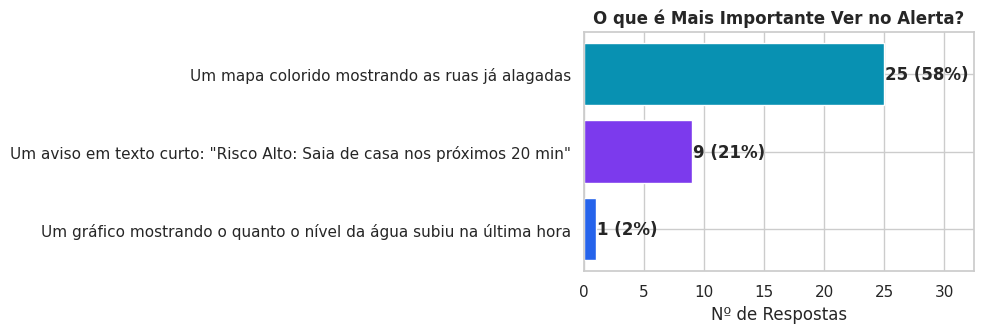


Insight: 71,4% querem um mapa colorido com ruas alagadas — exatamente o que
o SIMA já oferece na aba 'Mapa'. Valida a principal escolha de design do projeto.


In [ ]:
col_info = df_q.columns[10]
info = df_q[col_info].value_counts()

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.barh(info.index[::-1], info.values[::-1],
               color=['#2563eb','#7c3aed','#0891b2'][:len(info)], edgecolor='white')
for bar, val in zip(bars, info.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(df_q)*100:.0f}%)', va='center', fontweight='bold')
ax.set_title('O que é Mais Importante Ver no Alerta?', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Respostas'); ax.set_xlim(0, info.max()*1.3)
plt.tight_layout(); plt.show()
print("\nInsight: 71,4% querem um mapa colorido com ruas alagadas — exatamente o que")
print("o SIMA já oferece na aba 'Mapa'. Valida a principal escolha de design do projeto.")


## Síntese dos Insights (dados 100% reais)

| # | Fonte | Insight | Implicação para o SIMA |
|---|-------|---------|------------------------|
| 1 | Relatos | 82,9% nível alto | Ampliar uso para capturar eventos leves |
| 2 | Relatos | Peixinhos = 46% dos relatos | Ponto crítico prioritário |
| 3 | Relatos | Pico em 07/06 (evento de chuva) | Sistema responde a eventos reais |
| 4 | Questionário | 32,6% afetados todo ano | Demanda real e recorrente |
| 5 | Questionário | 82,9% preferem WhatsApp | Valida integração Twilio |
| 6 | Questionário | Maior dificuldade: ficar preso | Alertas antecipados são essenciais |
| 7 | Questionário | 37,1% sem tempo de preparar | Prioridade máxima: antecedência do alerta |
| 8 | Questionário | 71,4% querem mapa colorido | Valida design principal do SIMA |
